📊 DATASET
    Study_Hours  Attendance  Result
0           1.0          45       0
1           1.5          50       0
2           2.0          52       0
3           2.5          55       0
4           3.0          58       0
5           3.5          60       0
6           4.0          65       1
7           4.5          68       1
8           5.0          70       1
9           6.0          75       1
10          6.5          80       1
11          7.0          82       1
12          8.0          88       1
13          9.0          92       1
14         10.0          95       1

📈 MODEL PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

🔲 CONFUSION MATRIX
[[1 0]
 [0 2]]

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
w

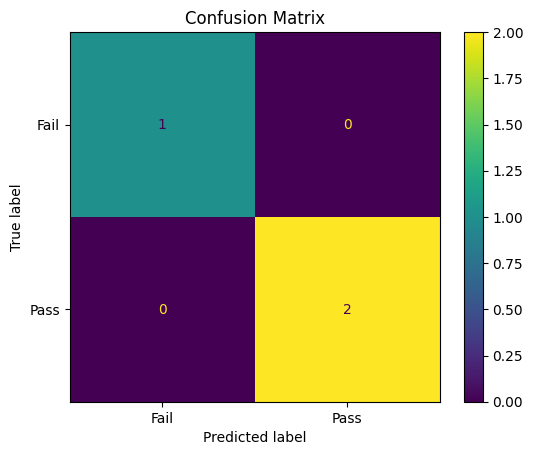

In [1]:
# 📊 Day 27 - Model Evaluation & Performance Metrics
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# 1. Create Dataset
data = {
    "Study_Hours": [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6, 6.5, 7, 8, 9, 10],
    "Attendance": [45, 50, 52, 55, 58, 60, 65, 68, 70, 75, 80, 82, 88, 92, 95],
    "Result": [
        0, 0, 0, 0, 0,
        0, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print("📊 DATASET")
print(df)

# 2. Select Features and Target
X = df[["Study_Hours", "Attendance"]]
y = df["Result"]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression Model
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# 6. Make Predictions
y_pred = model.predict(X_test_scaled)

# 7. Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n📈 MODEL PERFORMANCE")
print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\n🔲 CONFUSION MATRIX")
print(cm)

# 9. Classification Report
print("\n📋 CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# 10. Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()